# 026 从标量计算图推导反向传播

## 目标
从一张共享参数的标量图，逐边核验局部导数与总梯度。先修011、025；所有量为无量纲标量。本Notebook补充正文，不使用矩阵或深度学习框架。

## 设置
请在本单元目录重启内核后顺序运行。首格先核对默认配置和五份教学输出；不匹配便停止，不使用固定文字解释自定义结果。

In [1]:
from pathlib import Path
import sys, json, csv, math
import experiment as e
e.require_teaching_inputs()
print("Python", sys.version.split()[0])
print("Fixed config and five outputs verified; core uses standard library only.")

Python 3.12.14
Fixed config and five outputs verified; core uses standard library only.


## 步骤
### 1 先看完整前向账本
模型s=(wx+b)^2+w，目标L=(s−y)^2/2。w出现在两条路径；只更新w与b。

In [2]:
nodes = e.example()
grad = e.backward(nodes["L"])
for name, node in nodes.items():
    print(f"{name:>2}: value={node.value: .9f}, dL/dnode={grad[node]: .9f}")
assert nodes["L"].value == 169/512
assert grad[nodes["w"]] == 13/4
assert grad[nodes["b"]] == 39/32

 x: value= 2.000000000, dL/dnode= 0.609375000
 y: value= 0.250000000, dL/dnode=-0.812500000
 w: value= 0.500000000, dL/dnode= 3.250000000
 b: value=-0.250000000, dL/dnode= 1.218750000
 m: value= 1.000000000, dL/dnode= 1.218750000
 a: value= 0.750000000, dL/dnode= 1.218750000
 h: value= 0.562500000, dL/dnode= 0.812500000
 s: value= 1.062500000, dL/dnode= 0.812500000
 e: value= 0.812500000, dL/dnode= 0.812500000
 q: value= 0.660156250, dL/dnode= 0.500000000
 L: value= 0.330078125, dL/dnode= 1.000000000


### 2 图的节点数与边数为何不同？
11个命名量以外还包含负号和常数实现节点；两个相同输入位置保留两条边。

In [3]:
order = e.topological(nodes["L"])
print("nodes:", len(order), "edges:", sum(len(v.parents) for v in order))
for parent, local in nodes["h"].parents:
    print("h input is a:", parent is nodes["a"], "local:", local,
          "contribution:", grad[nodes["h"]]*local)
assert len(order) == 13
assert len(nodes["h"].parents) == 2

nodes: 13 edges: 15
h input is a: True local: 0.75 contribution: 0.609375
h input is a: True local: 0.75 contribution: 0.609375


### 3 完整反向图
框内显示相对于同一L的总梯度。w的上方路线直接贡献13/16，另一条贡献39/16。

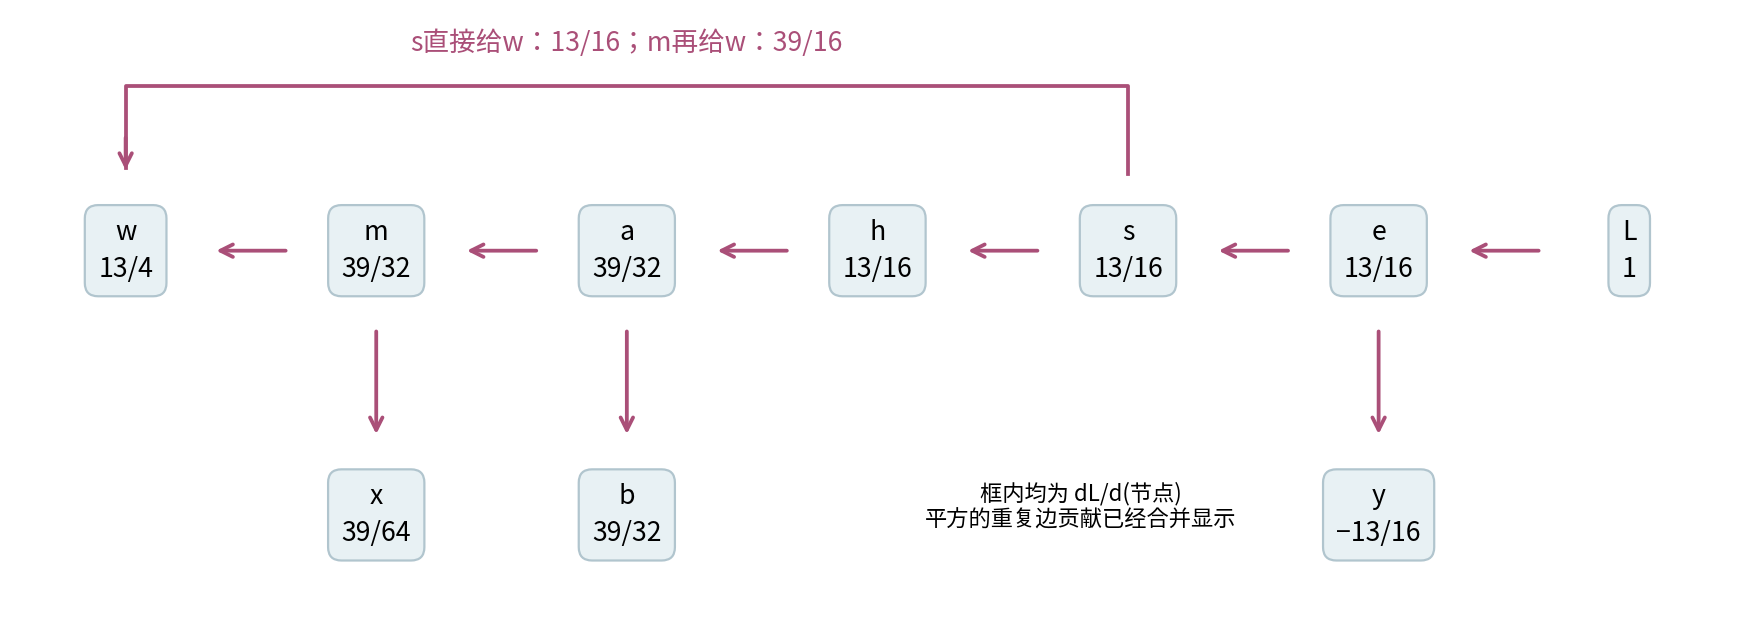

In [4]:
from IPython.display import display, Image
e.require_teaching_inputs()
display(Image(filename="figures/10_complete_backward.png", width=950))

### 4 独立代数表达式核验
先代回所有中间量，再手动求偏导，得到e(2ax+1)、2ae。此路线不读取图中的局部偏导记录。

In [5]:
reference = e.explicit_gradient(2., .25, .5, -.25)
for name, value in reference.items():
    print(name, "expanded:", value, "graph:", grad[nodes[name]])
    assert value == grad[nodes[name]]

w expanded: 3.25 graph: 3.25
b expanded: 1.21875 graph: 1.21875
x expanded: 0.609375 graph: 0.609375
y expanded: -0.8125 graph: -0.8125


### 5 共享节点与重复边
同一个t的反向规则执行一次；同一个乘法的两个输入位置仍各贡献一次。

In [6]:
w = e.Scalar(2., name="w")
t = w*w
loss = t+t+w
g = e.backward(loss)
other = e.Scalar(2., name="w")
print("loss", loss.value, "gradient", g[w], "nodes", len(e.topological(loss)))
print("new same-valued leaf is reachable:", other in g)
assert (loss.value, g[w], len(e.topological(loss))) == (10., 9., 4)
assert other not in g

loss 10.0 gradient 9.0 nodes 4
new same-valued leaf is reachable: False


### 6 重复调用和seed不等于参数更新
本教学API每次返回新字典，没有跨调用.grad缓存。seed缩放目标的导数。

In [7]:
g1, g2 = e.backward(loss), e.backward(loss)
g3 = e.backward(loss, seed=3.)
assert g1 == g2 and g1 is not g2
assert all(g3[v] == 3*g1[v] for v in g1)
print("two fresh maps, same values:", g1 == g2, "seed=3 gradient:", g3[w])
print("w remains:", w.value)

two fresh maps, same values: True seed=3 gradient: 27.0
w remains: 2.0


### 7 数值相同仍可能已经切断依赖
先保存a.value，再重新创建叶子，会改变对原w的导数。

In [8]:
a = w*w
connected = a+w
disconnected = e.Scalar(a.value)+w
print("equal forward:", connected.value, disconnected.value)
print("different gradients:", e.backward(connected)[w], e.backward(disconnected)[w])
assert connected.value == disconnected.value
assert e.backward(connected)[w] == 5 and e.backward(disconnected)[w] == 1

equal forward: 6.0 6.0
different gradients: 5.0 1.0


### 8 差分误差扫描
用不同步长检验相同标量目标，不以某个最佳步长替代完整检查。ReLU零点单独处理。

w absolute error 1.0189182830799837e-11
b absolute error 2.3934632054078975e-11


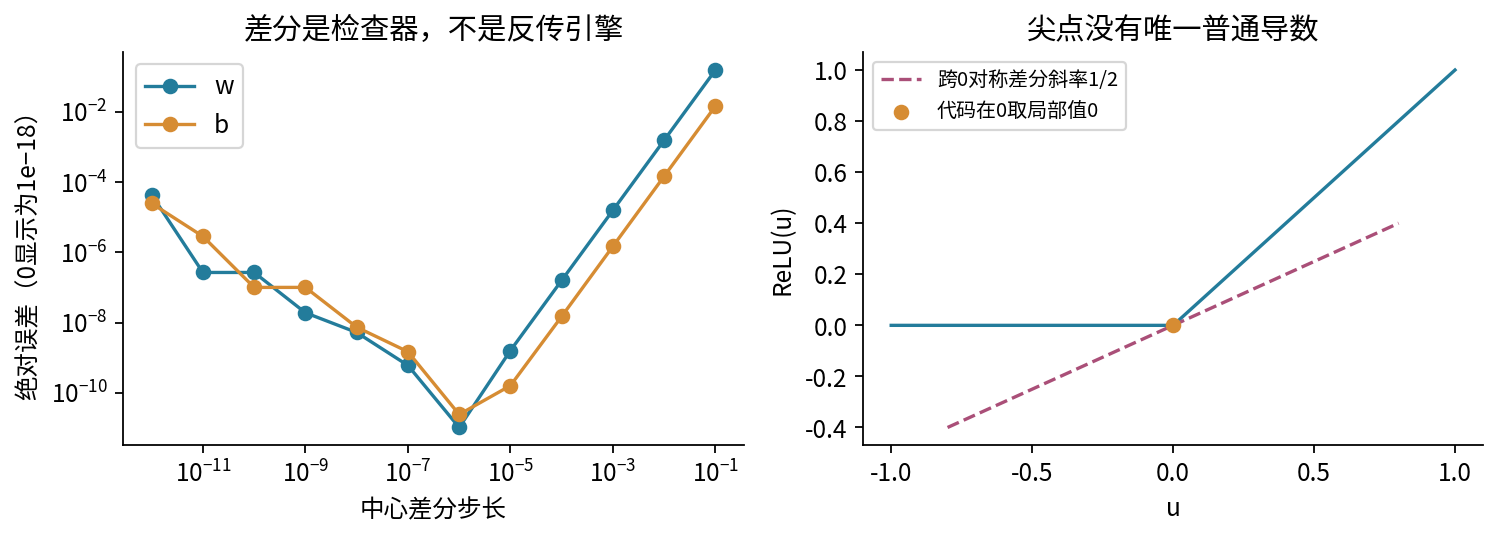

In [9]:
e.require_teaching_inputs()
checks = list(csv.DictReader(Path("outputs/gradient_check.csv").open()))
for row in checks:
    if float(row["step"]) == 1e-6:
        print(row["parameter"], "absolute error", row["absolute_error"])
        assert float(row["absolute_error"]) < 1e-9
display(Image(filename="figures/06_checks_and_kinks.png", width=950))

### 9 非光滑点与数值饱和
ReLU零点普通导数不存在；代码约定0和对称差分1/2回答的不是同一命题。tanh的实数等价局部公式也有不同数值表现。

In [10]:
u = e.Scalar(0.); step=1e-6
print("ReLU convention:", e.backward(u.relu())[u])
print("ReLU centered difference:", (max(step,0)-max(-step,0))/(2*step))
v = e.Scalar(20.)
print("tanh naive:", 1-math.tanh(20.)**2, "stable:", e.backward(v.tanh())[v])
assert e.backward(u.relu())[u] == 0
assert e.backward(v.tanh())[v] > 0

ReLU convention: 0.0
ReLU centered difference: 0.5
tanh naive: 0.0 stable: 1.6993417021166355e-17


## 检查
### 10 独立参照与失败用例
自动运行完整测试：分数前向敏感度、展开多项式、高精度激活、共享路径、长链、JSON和新旧输出保护。保留有限覆盖的边界。

In [11]:
import unittest, io
import test_experiment
stream=io.StringIO()
result=unittest.TextTestRunner(stream=stream, verbosity=0).run(unittest.defaultTestLoader.loadTestsFromModule(test_experiment))
assert result.wasSuccessful(), stream.getvalue()
print("Test groups passed:", result.testsRun)

Test groups passed: 13


### 11 在新目录运行，并与随附结果逐字节比较
完整run在输出之前完成输入、数值和序列化检查；它不承诺操作系统多文件写入原子性。

In [12]:
e.require_teaching_inputs()
summary = e.run(output="notebook_outputs")
for name in e.OUTPUT_NAMES:
    assert (Path("notebook_outputs")/name).read_bytes() == (Path("outputs")/name).read_bytes()
print("All five outputs match byte for byte.")
print("Final loss:", summary["final"]["loss"])

All five outputs match byte for byte.
Final loss: 0.00012753874150921865


### 12 从求导到同步更新
每步用旧参数一起求梯度，再一起更新w和b，并用新叶子重建图。这个轨迹只拟合一条合成记录。

first update {'step': '1', 'w': '0.435', 'b': '-0.274375', 'prediction': '0.789769140625', 'loss': '0.14567536258552552', 'gradient_w': '1.8257691181640627', 'gradient_b': '0.6429999887695313'}
last update {'step': '40', 'w': '0.242368490080261', 'b': '-0.33110542335802723', 'prediction': '0.2659711453258192', 'loss': '0.00012753874150921865', 'gradient_w': '0.025785833007117207', 'gradient_b': '0.004907343840648991'}


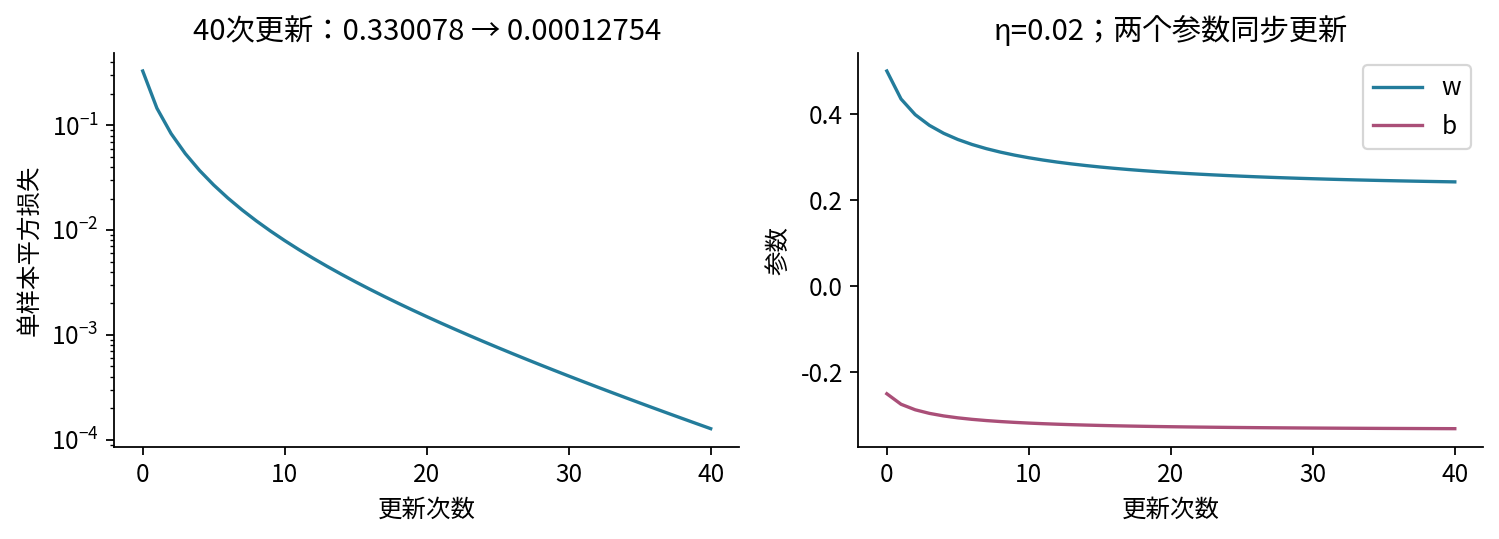

In [13]:
e.require_teaching_inputs()
rows = list(csv.DictReader(Path("outputs/training.csv").open()))
assert len(rows) == 41
print("first update", rows[1])
print("last update", rows[-1])
display(Image(filename="figures/08_training.png", width=950))

### 13 验证非唯一性
先给出两个完全不同的参数解，再讨论为什么单样本损失下降不足以识别参数。

In [14]:
for ww, bb in [(0.25,-0.5),(0.,0.5),(0.,-0.5)]:
    value=e.example(w=ww,b=bb)["L"].value
    print("w, b, L:", ww,bb,value)
    assert value == 0.
print("Finite toy checks do not establish real-world generalization.")

w, b, L: 0.25 -0.5 0.0
w, b, L: 0.0 0.5 0.0
w, b, L: 0.0 -0.5 0.0
Finite toy checks do not establish real-world generalization.


## 下一步
完成lab.pdf中的纸笔边贡献表与失败解释，检查answers.pdf。027将把同一链式原则推广到批次矩阵和损失归约。

实际已检查新Python进程中的真实InProcessKernel；没有验证浏览器Jupyter、外部socket内核、全新Anaconda或GPU。高阶导数、广播和一般幂运算不在本引擎范围。